In [79]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [80]:
rfm = pd.read_csv('Data/Processed/rfm_table.csv', index_col=0)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


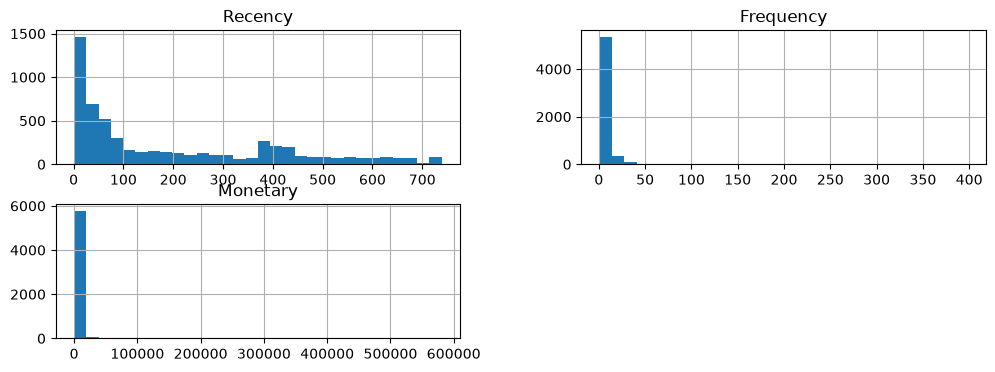

In [81]:
rfm.hist(
    figsize=(12,4),
    bins=30
)
plt.show()

In [82]:
#Log Transformation

rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(
    rfm_log["Recency"]
)

rfm_log["Frequency"] = np.log1p(
    rfm_log["Frequency"]
)

rfm_log["Monetary"] = np.log1p(
    rfm_log["Monetary"]
)

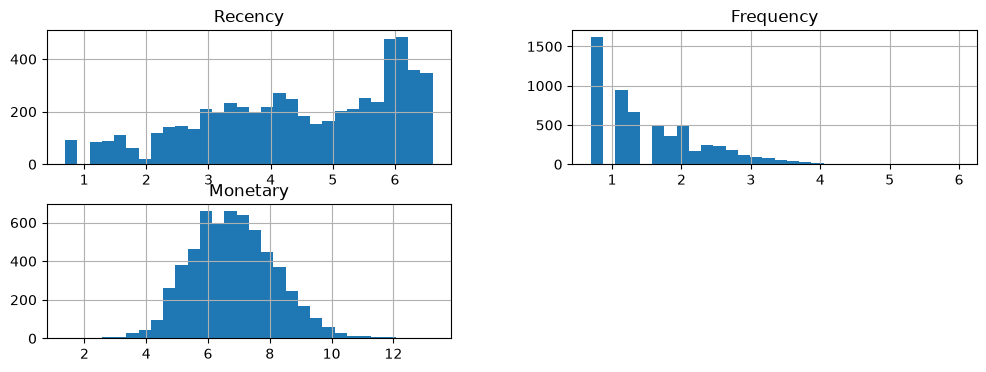

In [83]:
rfm_log.hist(
    figsize=(12,4),
    bins=30
)

plt.show()

# Standar Scaler 


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log
)
rfm_scaled

array([[ 0.85670058,  1.25449595,  3.20621937],
       [-2.15197903,  0.80016603,  1.21599349],
       [-0.07913835,  0.29920733,  0.57318471],
       ...,
       [ 1.3090307 , -1.05814595, -0.54704249],
       [ 1.10018005, -0.55718724,  0.25347909],
       [-0.42965061,  0.65464319,  1.09865484]], shape=(5878, 3))

In [85]:
from sklearn.cluster import KMeans
wcss = []

In [86]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(
        kmeans.inertia_
    )

wcss

[8588.985343295879,
 6354.343153426074,
 4921.2333452738085,
 4099.10607877831,
 3554.696268860984,
 3194.500971551539,
 2902.433884952622,
 2656.5623279084407,
 2467.3784663539077]

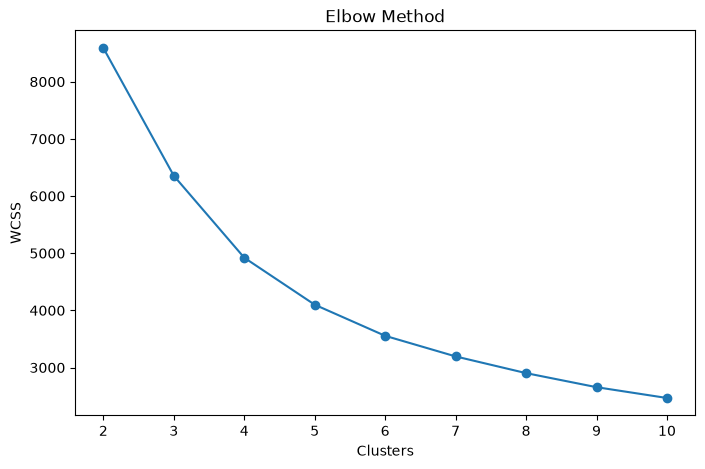

In [87]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [88]:
#The curve starts flattening significantly after:
#K = 5
#Train Final KMeans

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    rfm_scaled
)

rfm["Cluster"] = clusters
rfm

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,2
12348.0,75,5,2019.40,2
12349.0,19,4,4428.69,2
12350.0,310,1,334.40,4
...,...,...,...,...
18283.0,4,22,2664.90,0
18284.0,432,1,461.68,4
18285.0,661,1,427.00,4


In [89]:
#Calculate Silhouette Score

from sklearn.metrics import silhouette_score

score = silhouette_score(
    rfm_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.3424961358761568


In [91]:
rfm["Cluster"].value_counts()

Cluster
4    1620
1    1363
2    1294
3    1143
0     458
Name: count, dtype: int64

In [92]:
#install pca visualisation
from sklearn.decomposition import PCA

In [93]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(
    rfm_scaled
)

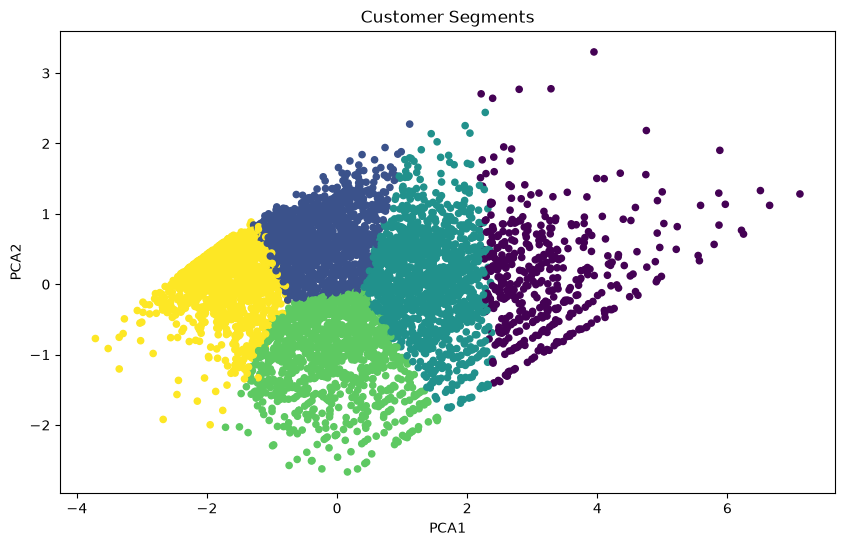

In [94]:
plt.figure(figsize=(10,6))

plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=20
)

plt.title("Customer Segments")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

In [96]:
#Analyse cluster centre
cluster_summary = (
    rfm.groupby("Cluster")
       .agg({
           "Recency":"mean",
           "Frequency":"mean",
           "Monetary":"mean"
       })
       .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,18.06,32.90,20817.59
1,293.71,3.80,1385.85
2,48.87,9.13,3673.51
3,32.46,2.53,682.55
4,416.35,1.25,257.87


In [98]:
# create segment columns

segment_map = {
    0: "VIP Customers",
    2: "Loyal Customers",
    3: "Regular Customers",
    1: "At-Risk Customers",
    4: "Lost Customers"
}

rfm["Segment"] = (
    rfm["Cluster"]
    .map(segment_map)
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,2,Loyal Customers
12347.0,2,8,4921.53,2,Loyal Customers
12348.0,75,5,2019.40,2,Loyal Customers
12349.0,19,4,4428.69,2,Loyal Customers
12350.0,310,1,334.40,4,Lost Customers


In [99]:
rfm["Segment"].value_counts()

Segment
Lost Customers       1620
At-Risk Customers    1363
Loyal Customers      1294
Regular Customers    1143
VIP Customers         458
Name: count, dtype: int64

In [100]:
rfm.to_csv(
    "Data/Processed/customer_segments.csv"
)